# Topic:


> Text Mining and Topic Modeling of Food & Bakery App Reviews




## Submitted By:

*  Azka Aziz (FA24-BBD-023)
*  Noor Ul Ain Zahid (FA24-BBD-069)
*  Rida Chaudary (FA24-BBD-075)

## Submitted To:

   Prof. Abdul Hannan




## Install and Load Libraries

In [ ]:
system('apt-get update')
system('apt-get install -y gfortran r-base-dev libxml2-dev libssl-dev libcurl4-openssl-dev libgsl-dev')

# Install core R dependencies first
install.packages(c("Rcpp", "RcppArmadillo"))

# Install topicmodels separately
install.packages("topicmodels")

# Install remaining text mining, topic modeling, and visualization libraries
install.packages(c("tm", "textstem", "tidyverse", "tidytext",
                   "reshape2", "wordcloud", "pals", "stringr", "slam", "LDAvis"))

# Load the libraries
library(tm)
library(textstem)
library(tidyverse)
library(tidytext)
library(topicmodels)
library(reshape2)
library(wordcloud)
library(pals)
library(stringr)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Loading required package: RColorBrewer



## Import Data

In [ ]:
# Instead of choose.files() which crashes on a server, we read directly from Colab storage
reviews_df <- read.csv("Multiple_Apps_Reviews.csv", stringsAsFactors = FALSE)

# Extract only the content column containing text reviews
hsp <- reviews_df$content

# View the first few lines to make sure it loaded correctly
head(hsp, 3)

[1] "too much slow processing of app" "very testy"                     
[3] "too difficult to order"

## Text Pre-processing and Cleaning Pipeline

In [ ]:
# Convert text to lowercase
hsp <- tolower(hsp)

# Clean specific patterns (URLs, handles, punctuation, and numbers)
hsp <- gsub("@\\w+", "", hsp)
hsp <- gsub("https?://.+", "", hsp)
hsp <- gsub("\\d+\\w*\\d*", "", hsp)
hsp <- gsub("#\\w+", "", hsp)
hsp <- gsub("[^\x01-\x7F]", "", hsp) # Removes emojis/non-ASCII characters
hsp <- gsub("[[:punct:]]", " ", hsp)
hsp <- gsub("\n", " ", hsp)
hsp <- gsub("^\\s+", "", hsp)
hsp <- gsub("\\s+$", "", hsp)
hsp <- gsub("[ |\t]+", " ", hsp)
hsp <- gsub("[[:digit:]]", " ", hsp)
hsp <- stripWhitespace(hsp)

# Fixed bug: Safely check and remove non-English characters if index matches exist
hsp1 <- grep('hsp', iconv(hsp, 'latin1', 'ASCII', sub='hsp'))
if(length(hsp1) > 0) {
  hsp <- hsp[-hsp1]
}

# Remove standard English stopwords
hsp <- removeWords(hsp, stopwords("en"))
hsp <- stripWhitespace(hsp)

# Remove custom application stopwords
wo <- c("dr", "doctor")
hsp <- removeWords(hsp, wo)
hsp <- stripWhitespace(hsp)

# Clean remaining single letters
hsp <- gsub(pattern = "\\W", replacement = " ", hsp)
hsp <- gsub(pattern = "\\b[a-z]\\b{1}", replacement = " ", hsp)
hsp <- stripWhitespace(hsp)

# Apply Text Stemming
hsp <- stemDocument(hsp)

# Final formatting sweep
hsp <- str_replace_all(hsp, "[^[:graph:]]", " ")
hsp <- str_replace_all(hsp, 'https', " ")
hsp <- str_replace_all(hsp, 'amp', " ")
hsp <- stripWhitespace(hsp)

## Interpretation:

This code cleans messy review text by removing links, emojis, punctuation, numbers, and common words, and then converts words into their root form so the data becomes simple and consistent for analysis.

## Document-Term Matrix (DTM) Construction

In [ ]:
# Convert cleaned text to a volatile corpus object
hsp_source <- VectorSource(hsp)
hsp_corpus <- VCorpus(hsp_source)

# Compute DTM (keeping words appearing at least 5 times globally)
minimumFrequency <- 5
DTM <- DocumentTermMatrix(hsp_corpus, control = list(bounds = list(global = c(minimumFrequency, Inf))))

# Fixed bug: Empty document rows cause LDA models to fail. We prune them here.
sel_idx <- slam::row_sums(DTM) > 0
DTM <- DTM[sel_idx, ]

print("Dimensions of the final DTM:")
print(dim(DTM))


[1] "Dimensions of the final DTM:"
[1] 3556  778


## Interpretation:

This step converts cleaned reviews into a numerical table (Document-Term Matrix) where each row is a review and each column is a word, showing how often each word appear

## Term Frequency Distribution

In [ ]:
# Note: memory.limit() was removed here because it's Windows-only and errors out on Colab.
wordCounts <- colSums(as_tibble(as.matrix(DTM)))
wordNames <- names(as_tibble(as.matrix(DTM)))

# Display Top 20 terms
top_20 <- tibble(wordNames, wordCounts) %>%
  arrange(desc(wordCounts)) %>%
  top_n(20)

print(top_20)

Selecting by wordCounts


# A tibble: 20 × 2
   wordNames wordCounts
   <chr>          <dbl>
 1 app             1385
 2 cooki            931
 3 order            875
 4 good             556
 5 best             406
 6 love             361
 7 use              342
 8 work             339
 9 deliveri         316
10 great            308
11 servic           301
12 easi             297
13 time             270
14 get              204
15 deliv            176
16 can              163
17 just             159
18 updat            156
19 place            147
20 tri              142


## Interpretation:

The output shows a list of the top 20 most frequent words, with general terms like "app" (1,385 times), "cooki" (931 times), and "order" (875 times) leading the pack. It gives you a great birds-eye view of your data, showing a mix of highly positive feedback (words like "good," "best," "love," and "great") alongside functional topics like "delivery," "service," and "update."

## Evaluate Optimal Topic Count using Perplexity


In [ ]:
# Calculate perplexity for a range of topic numbers
# This process can be computationally intensive, so we limit the range and iterations.
topic_numbers <- seq(2, 20, by = 1)
perplexity_values <- c()

for (k in topic_numbers) {
  set.seed(9161) # For reproducibility
  lda_model <- LDA(DTM, k, method = "Gibbs", control = list(iter = 500, verbose = 0))
  perplexity_score <- perplexity(lda_model, DTM)
  perplexity_values <- c(perplexity_values, perplexity_score)
  print(paste0("Topics: ", k, ", Perplexity: ", perplexity_score))
}

# Creating a data frame for plotting
perplexity_df <- data.frame(Topics = topic_numbers, Perplexity = perplexity_values)

[1] "Topics: 2, Perplexity: 286.837204765"
[1] "Topics: 3, Perplexity: 276.950518244148"
[1] "Topics: 4, Perplexity: 273.329783622848"
[1] "Topics: 5, Perplexity: 267.694187504803"
[1] "Topics: 6, Perplexity: 264.136326954607"
[1] "Topics: 7, Perplexity: 261.103025887914"
[1] "Topics: 8, Perplexity: 255.985824487622"
[1] "Topics: 9, Perplexity: 255.33058242382"
[1] "Topics: 10, Perplexity: 250.754812431072"
[1] "Topics: 11, Perplexity: 249.384688491875"
[1] "Topics: 12, Perplexity: 248.484731853343"
[1] "Topics: 13, Perplexity: 247.015373444823"
[1] "Topics: 14, Perplexity: 245.261675277444"
[1] "Topics: 15, Perplexity: 243.959713437942"
[1] "Topics: 16, Perplexity: 242.279047755263"
[1] "Topics: 17, Perplexity: 239.020969295944"
[1] "Topics: 18, Perplexity: 239.263418193081"
[1] "Topics: 19, Perplexity: 237.586607452537"
[1] "Topics: 20, Perplexity: 238.095960011045"


## Interpretation:
The output displays the confusion score for each number of topics, showing that as the number of topics grows from 2 to 20, the score drops from roughly 286 down to 238. In simple terms, this means the computer is getting much better at sorting and understanding the reviews when it groups them into a larger number of specific topics rather than just a few broad ones.

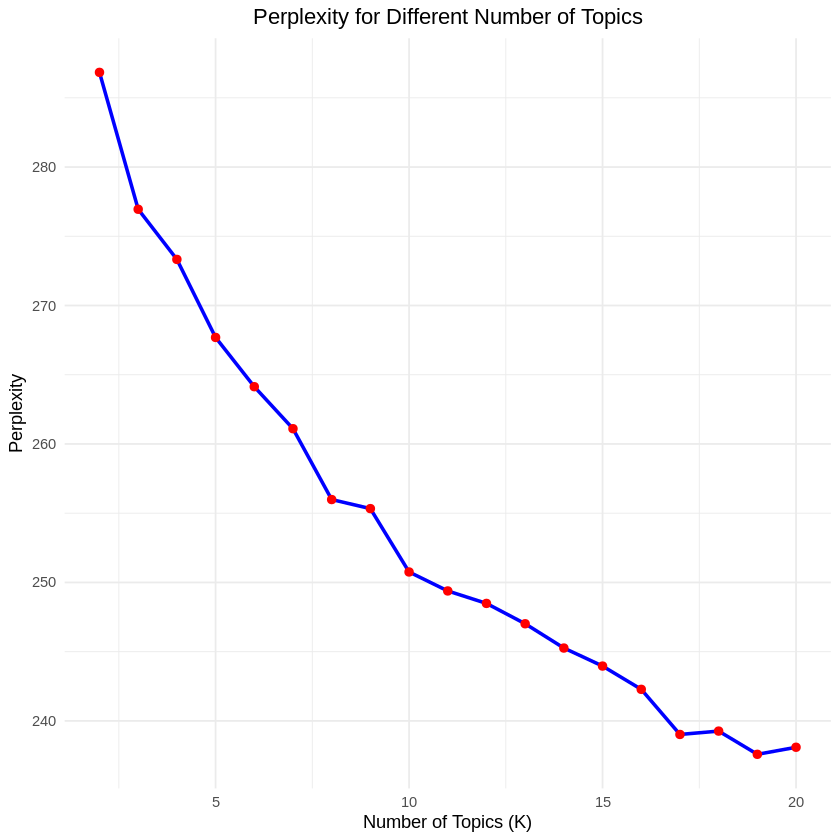

In [ ]:
# Plot the perplexity values
ggplot(perplexity_df, aes(x = Topics, y = Perplexity)) +
  geom_line(color = "blue", linewidth = 1) +
  geom_point(color = "red", size = 2) +
  labs(title = "Perplexity for Different Number of Topics",
       x = "Number of Topics (K)",
       y = "Perplexity") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

## Interpretation:
This graph shows how the model performs as the number of topics increases. The error drops quickly at first and then levels off, meaning after around 10 topics, adding more doesn’t improve results much.

## Train LDA Topic Model

In [ ]:
# Choose target number of topics (K)
K <- 6
set.seed(9161)

# Fit LDA model via Gibbs Sampling inference
topicModel <- LDA(DTM, K, method = "Gibbs", control = list(iter = 500, verbose = 25))

# Extract term distribution assignments (Beta) and document weights (Theta)
tmResult <- posterior(topicModel)
beta <- tmResult$terms
theta <- tmResult$topics

# Show 10 most likely words defining each topic
terms(topicModel, 10)

K = 6; V = 778; M = 3556
Sampling 500 iterations!
Iteration 25 ...
Iteration 50 ...
Iteration 75 ...
Iteration 100 ...
Iteration 125 ...
Iteration 150 ...
Iteration 175 ...
Iteration 200 ...
Iteration 225 ...
Iteration 250 ...
Iteration 275 ...
Iteration 300 ...
Iteration 325 ...
Iteration 350 ...
Iteration 375 ...
Iteration 400 ...
Iteration 425 ...
Iteration 450 ...
Iteration 475 ...
Iteration 500 ...
Gibbs sampling completed!


Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6
app,order,use,good,servic,cooki
work,time,app,best,deliveri,love
get,just,tri,app,order,great
updat,address,can,qualiti,deliv,easi
doesn,locat,like,tast,call,alway
store,one,option,food,experi,delici
even,give,payment,nice,custom,amaz
point,don,add,excel,bad,ever
issu,app,need,realli,worst,quick
pleas,let,card,shezan,item,fresh


# Interpretation:
The analysis of 3,556 customer reviews identified 6 main discussion topics. Customers mainly talked about app performance and usability issues, ordering and delivery processes, and payment-related concerns, while many reviews also shared positive experiences about food quality, taste, and freshness.

##

## Plot Topic Visualizations (ggplot2 Bar Charts)

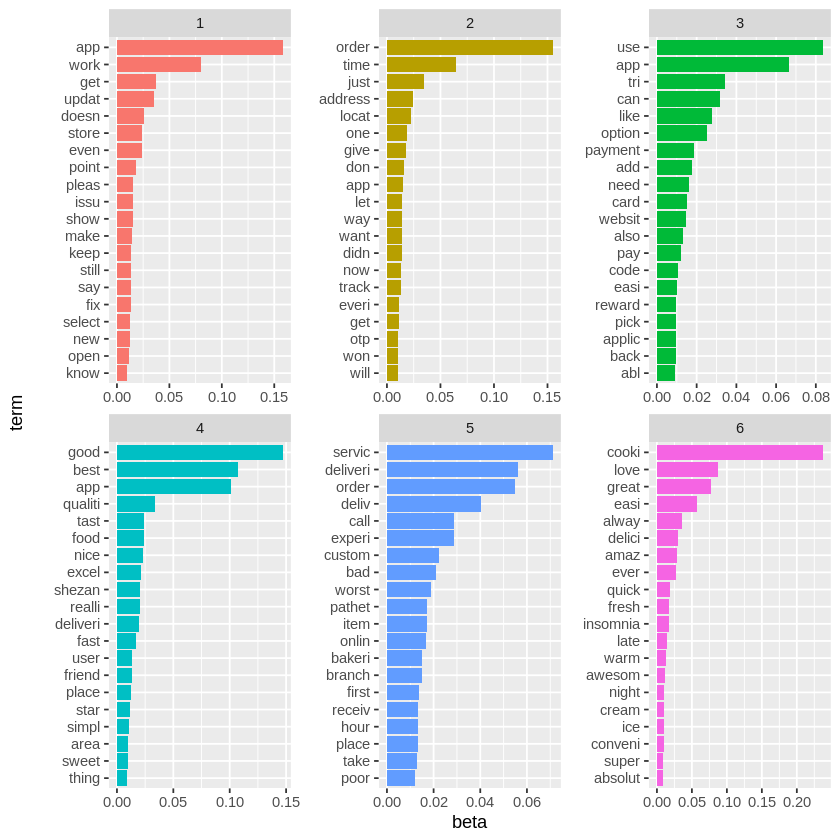

In [ ]:
lda_beta <- tidy(topicModel, matrix = "beta")

top_terms <- lda_beta %>%
  group_by(topic) %>%
  slice_max(beta, n = 20) %>%
  ungroup() %>%
  arrange(topic, -beta)

# Plot charts side-by-side inside Colab
top_terms %>%
  mutate(term = reorder_within(term, beta, topic)) %>%
  ggplot(aes(beta, term, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free") +
  scale_y_reordered()

## Interpretation:
The LDA visualization shows the top 20 most important words for each of the 6 topics identified from the customer reviews. The size of each bar represents the beta (β) probability, meaning that words with higher values are more strongly associated with a specific topic. Overall, the results reveal that customer discussions mainly focus on app performance and technical issues, payment and delivery operations, and positive feedback related to food quality, taste, and freshness.

## Compile Interactive Dashboard File Exports


In [ ]:
topicmodels2LDAvis <- function(x, ...){
  post <- topicmodels::posterior(x)
  if (ncol(post[["topics"]]) < 3) stop("The model must contain > 2 topics")
  mat <- x@wordassignments
  LDAvis::createJSON(
    phi = post[["terms"]],
    theta = post[["topics"]],
    vocab = colnames(post[["terms"]]),
    doc.length = slam::row_sums(mat, na.rm = TRUE),
    term.frequency = slam::col_sums(mat, na.rm = TRUE)
  )
}

# Compile the JSON metadata
json <- topicmodels2LDAvis(topicModel)

# Fixed bug: Local browser launch fails in Colab.
# This command instead exports the interactive web files right to a folder in your file tab.
# Load LDAvis specifically for this cell if it hasn't been loaded globally
library(LDAvis)
serVis(json, out.dir = 'LDAvis_Interactive_Report', open.browser = FALSE)
# Zip the entire folder into a single file named LDAvis_Report.zip
system("zip -r LDAvis_Report.zip LDAvis_Report")

Warning message in dir.create(out.dir):
“'LDAvis_Interactive_Report' already exists”
Loading required namespace: servr



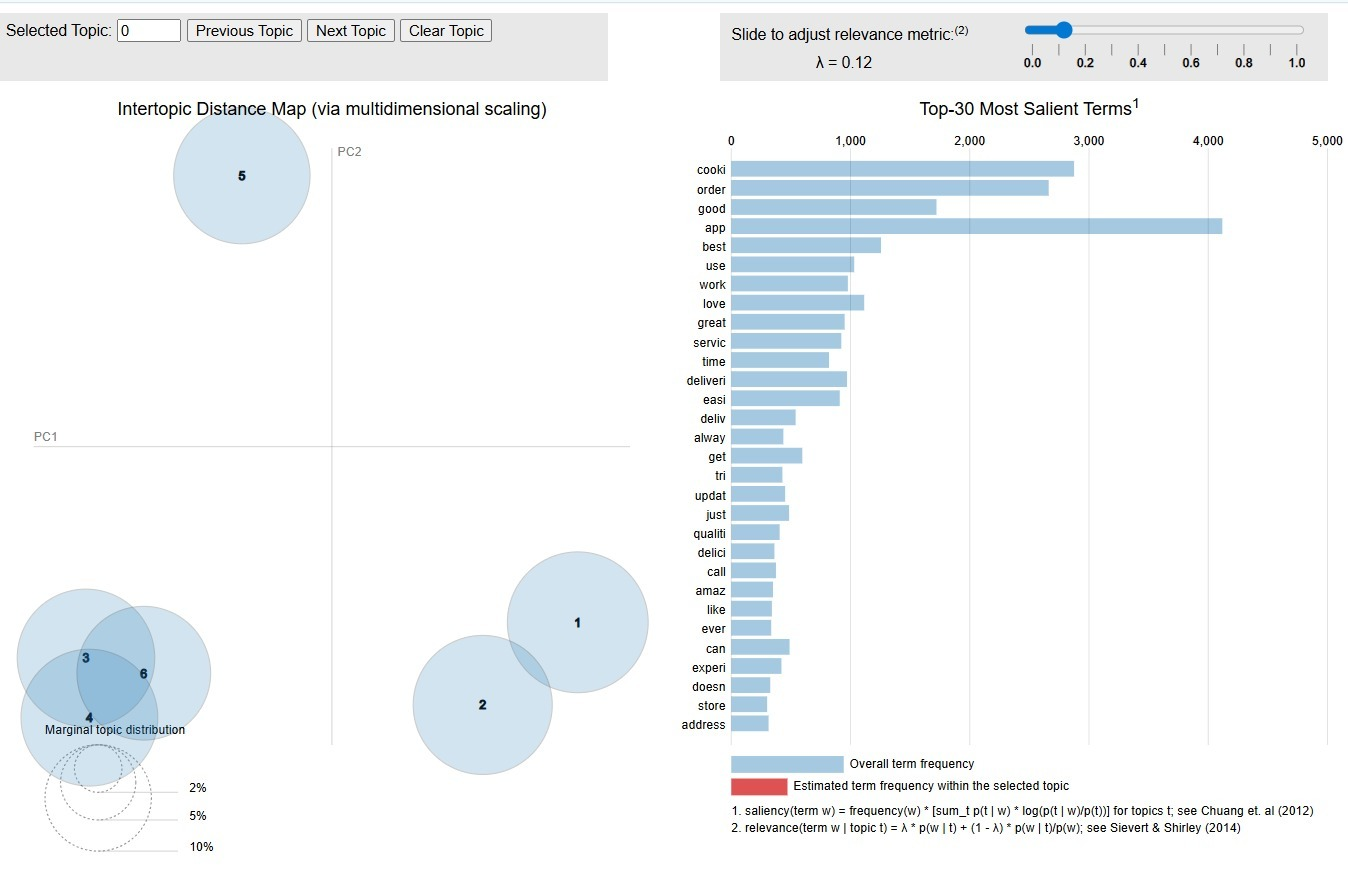

## Topic Word Clouds


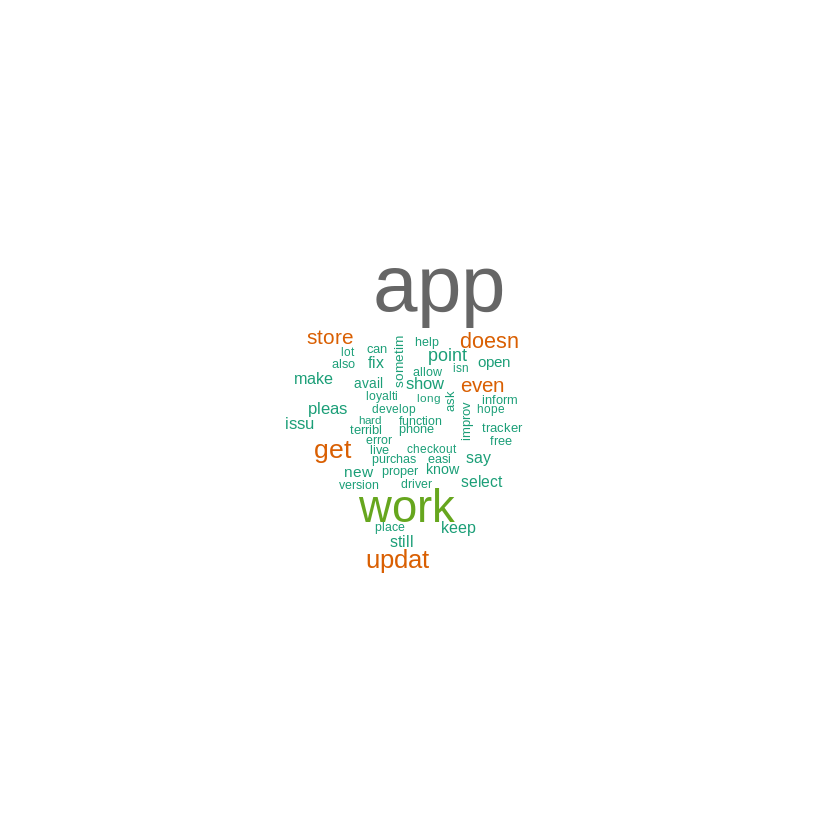

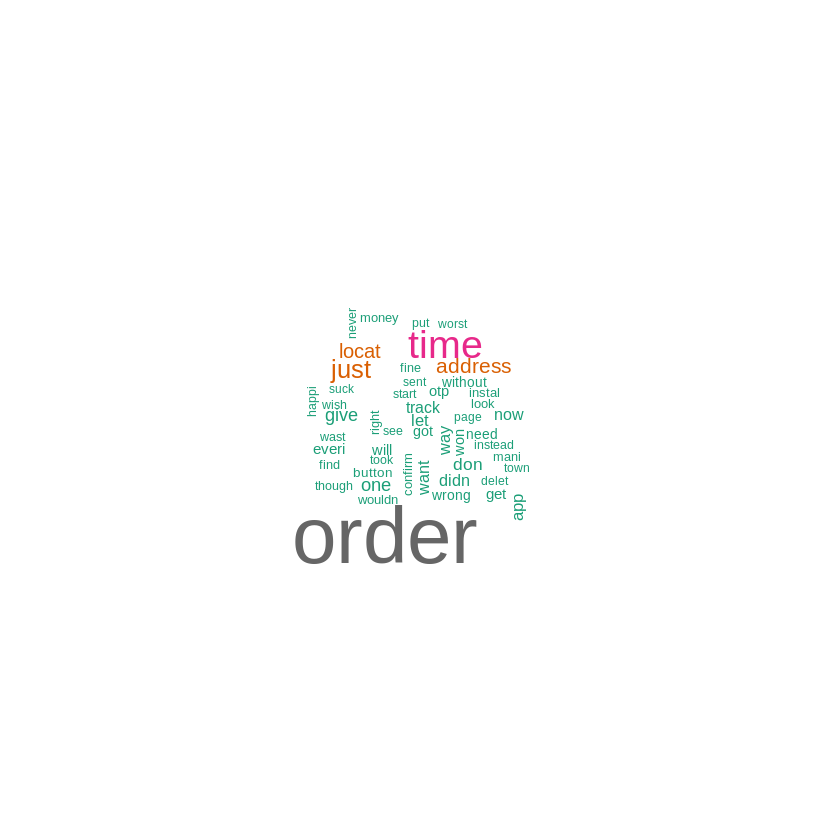

In [ ]:
# Split terms per individual topic layer
topic1_terms <- subset(lda_beta, lda_beta$topic == 1)[, 2:3]
topic2_terms <- subset(lda_beta, lda_beta$topic == 2)[, 2:3]

# Note: wordcloud2 uses an HTML canvas widget that sometimes goes blank in Colab iframes.
# Standard base 'wordcloud' is used here to guarantee perfect visual execution:
wordcloud(words = topic1_terms$term, freq = topic1_terms$beta, max.words = 50, colors = brewer.pal(8, "Dark2"))
wordcloud(words = topic2_terms$term, freq = topic2_terms$beta, max.words = 50, colors = brewer.pal(8, "Dark2"))

## Interpretation:
The word clouds provide a visual summary of the most frequently discussed terms within each topic. In these clouds, larger words represent terms that appear more often in customer reviews, indicating their stronger importance within that specific topic.
### First Wod Cloud:
The first word cloud mainly represents technical and software-related issues. Dominant words such as *app*, *use*, *work*, *issue*, *update*, and *doesn’t* show that customers frequently discussed app performance problems, bugs, and difficulties after software updates. This indicates that users are highly concerned about application stability and usability.


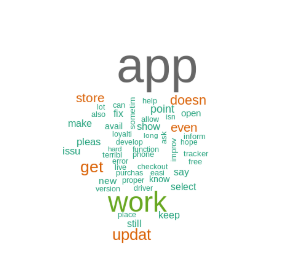

### Second Word Cloud

The second word cloud focuses on the ordering and transaction process. Frequently appearing words like *order*, *service*, *time*, *payment*, *card*, and *call* highlight customer experiences related to purchasing, payment handling, customer support, and delivery timing. This suggests that transaction efficiency and service responsiveness are key parts of the customer journey.


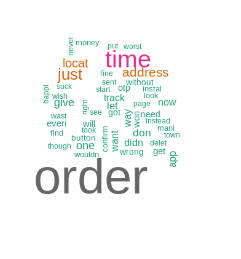

## Dataset Search and Filter

In [ ]:
# Query specific structural keywords from the original reviews dataset content column
rev_topic1 <- reviews_df %>%
  filter(grepl('satisf|good|experi|nice|cooper|chekup|check|appoint|wait|overal|also|full|total|allah|behavior|behaviour|environ', content, ignore.case = TRUE))

# View output size and match examples
print(dim(rev_topic1))
head(rev_topic1$content, 3)

[1] 973  12


[1] "Shop Ke Bahir Wait Krwa Ke Kehte Hain App Se Order Karain."
[2] "good👍"                                                    
[3] "good and excellent"

## Interpretation:
This output shows that 973 customer reviews matched the selected keywords related to service quality, waiting time, and customer satisfaction, while keeping all 12 dataset columns intact. The sample reviews demonstrate how words like *“wait”* and *“good”* triggered the filter, helping isolate reviews focused on customer experience and service behavior.



### **Overall Summary of Customer Review Analysis**

---

###  Data Overview

This study analyzed **3,556 customer reviews** from food and bakery mobile apps. After cleaning the data, **778 unique words** were used to identify patterns in customer feedback.

---

### Main Focus Areas in Reviews

Customer feedback mainly falls into three key areas:

* App performance and usability issues
* Ordering, payment, and delivery experience
* Food quality and product satisfaction

---

###  App Performance Issues

Many users talked about problems with the app such as bugs, crashes, and update issues. This shows that app stability and smooth performance are major concerns.

---

###  Ordering & Delivery Experience

Customers frequently discussed ordering, payment, delivery time, and customer service. This reflects how important a smooth and fast transaction process is for user satisfaction.

---

###  Food Quality & Satisfaction

Most product-related feedback was positive, especially about taste, freshness, and items like cookies. This shows strong customer satisfaction with the actual food products.

---

###  Final Insight

Overall, customers love the food quality, but the main improvement areas are **app performance and delivery efficiency** to enhance the overall user experience.
